# 989 firmas vs 20 firmas nuevas

Comparación d las 989 firmas originales contra las 20 firmas nuevas usando un preprocessing adaptado a:

**ABS + Savitzky-Golay D1 + SNV**, con:

- crop = 50:1500
- window = 71
- poly = 2
- deriv = 1

# Librerías y configuración

In [80]:
# %pip uninstall -y torch torchvision torchaudio
# %pip cache purge
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [81]:
import torch

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
torch cuda: 12.8
cuda available: True
GPU: NVIDIA TITAN RTX


In [82]:
import os, glob, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import joblib

from IPython.display import display
from scipy.signal import savgol_filter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

try:
    import pytorch_lightning as pl
except Exception:
    pl = None
    print("Advertencia: pytorch_lightning no está disponible. La parte CNN puede requerir instalarlo.")

# -------------------------
# Rutas
# -------------------------

NEW_SPECTRA_DIR = r"HDSP/FINAL_FIRMAS_MAT"
MAT_SPEC_KEY_NEW = r"reflectanciaSoil1570"

GT_20_MAT_PATH = r"HDSP/datos_gt_3.mat"
GT_VAR_NAME = "data"

TRAIN_SPECTRA_DIR = r"HDSP/FIRMAS_RECORTADAS_solito"
MAT_SPEC_KEY_TRAIN = r"firma_recortada"

GT_989_MAT_PATH = r"HDSP/datos_gt_2.mat"
GT_989_VAR_NAME = "gt"

GT_COLUMN_NAMES = [
    "Numero", "Carbono", "pH", "Ca", "Mg", "Na", "K",
    "Al", "P", "B", "Fe", "Mn", "Cu", "Zn", "CiC", "CE"
]

EXPECTED_SPEC_LEN = 1570

PRETRAINED_CKPTS = {
    "pH": r"HDSP/MEJORES_MODELOS/pH_best_model.ckpt",
    "Ca": r"HDSP/MEJORES_MODELOS/Ca_best_model.ckpt",
}

PRETRAINED_ARTIFACTS = {
    "pH": {
        "y_scaler": r"HDSP/MEJORES_MODELOS/pH_y_scaler.pkl",
        "config": r"HDSP/MEJORES_MODELOS/pH_preprocess_config.pkl",
    },
    "Ca": {
        "y_scaler": r"HDSP/MEJORES_MODELOS/Ca_y_scaler.pkl",
        "config": r"HDSP/MEJORES_MODELOS/Ca_preprocess_config.pkl",
    },
}

# -------------------------
# Experimento
# -------------------------

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

OUT_DIR = "cuadernillo_comparativo_989_vs_20"
os.makedirs(OUT_DIR, exist_ok=True)

# Nuevo preprocessing propuesto
FINAL_CROP_START = 50
FINAL_CROP_END = 1500
FINAL_SAVGOL_WINDOW = 71 #151
FINAL_SAVGOL_POLY = 2
FINAL_SAVGOL_DERIV = 1

# Modelos clásicos compactos
NEW_DOMAIN_REPEATS = [1, 5, 20]
PLS_COMPONENTS_GRID = [2, 5, 10]

# CNN Fine tuning
FINETUNE_EPOCHS = 15
FINETUNE_LR = 1e-5
BATCH_SIZE_FT = 4
FREEZE_MODE = "head"  # recomendado con 10 muestras: "head" o "stem_fc"

device = "cuda" if torch.cuda.is_available() else "cpu"
#device = "cpu"
print("Dispositivo:", device)
print("Carpeta de salida:", OUT_DIR)

Dispositivo: cuda
Carpeta de salida: cuadernillo_comparativo_989_vs_20


# Funciones de carga y métricas

In [83]:
def parse_file_id(path: str):
    base = os.path.basename(path)
    m = re.search(r"([0-9]+)", base)
    return int(m.group(1)) if m else None


def list_mat_files(sdir: str):
    files = glob.glob(os.path.join(sdir, "*.mat"))
    return sorted(files, key=lambda p: parse_file_id(p) or 0)


def load_mat_var(path: str, key: str) -> np.ndarray:
    try:
        d = sio.loadmat(path, squeeze_me=True, struct_as_record=False, simplify_cells=True)
        if key not in d:
            raise KeyError(f"Clave '{key}' no encontrada en {path}. Claves disponibles: {list(d.keys())}")
        arr = np.array(d[key])
    except NotImplementedError:
        import h5py
        with h5py.File(path, "r") as f:
            if key not in f:
                raise KeyError(f"Clave '{key}' no encontrada en {path}. Claves disponibles: {list(f.keys())}")
            arr = f[key][()]
    return np.asarray(arr)


def load_spectra_per_file(spectra_dir, mat_key):
    files = list_mat_files(spectra_dir)
    ids, Xs = [], []

    for p in files:
        fid = parse_file_id(p)
        R = load_mat_var(p, mat_key).astype(np.float32)
        R = np.squeeze(R)

        if R.ndim == 1:
            spec = R
        elif R.ndim == 2 and 1 in R.shape:
            spec = R.reshape(-1)
        elif R.ndim == 2:
            # Promedia el eje que deja una firma 1D.
            # Si hay duda, este punto debe revisarse contra el formato del .mat.
            if R.shape[0] >= R.shape[1]:
                spec = R.mean(axis=1)
            else:
                spec = R.mean(axis=0)
        else:
            raise ValueError(f"Forma inesperada en {p}: {R.shape}")

        ids.append(fid)
        Xs.append(spec.astype(np.float32))

    X_raw = np.stack(Xs, axis=0)
    ids = np.array(ids)

    print(f"Cargadas {len(ids)} muestras desde {spectra_dir}")
    print("Shape:", X_raw.shape)
    return ids, X_raw


def load_gt_from_mat_path(gt_mat_path, gt_var_name):
    gt = load_mat_var(gt_mat_path, gt_var_name)
    if gt.ndim != 2:
        raise ValueError(f"GT debe ser 2D, recibido {gt.shape}")

    N, M = gt.shape
    cols = GT_COLUMN_NAMES[:M] if len(GT_COLUMN_NAMES) >= M else (
        GT_COLUMN_NAMES + [f"Var{j}" for j in range(len(GT_COLUMN_NAMES), M)]
    )

    df = pd.DataFrame(gt, columns=cols[:M])
    df["Numero"] = df["Numero"].astype(int)
    return df


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "RMSE": float(np.sqrt(mse)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)) if len(np.unique(y_true)) > 1 else np.nan,
        "Bias": float(np.mean(y_pred - y_true)),
    }


def compact_describe(name, X):
    X = np.asarray(X)
    return {
        "conjunto": name,
        "shape": str(X.shape),
        "min": np.nanmin(X),
        "p1": np.nanpercentile(X, 1),
        "mediana": np.nanmedian(X),
        "media": np.nanmean(X),
        "p99": np.nanpercentile(X, 99),
        "max": np.nanmax(X),
        "std": np.nanstd(X),
        "%<=0": 100 * np.mean(X <= 0),
        "%>1": 100 * np.mean(X > 1),
    }


def show_compact_table(rows, title=None, decimals=4):
    df = pd.DataFrame(rows)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].round(decimals)
    if title:
        print("\n" + title)
    display(df)
    return df

# Preprocessing original y preprocessing nuevo

In [84]:
def select_band_slice(T: int, mode: str):
    if mode == "ALL":
        return slice(0, T)
    if mode == "RE1":
        return slice(68, 226)
    if mode == "RE2":
        return slice(288, 449)
    return slice(0, T)


def to_absorbance(X):
    return np.log10(1.0 / np.clip(X, 1e-6, None))


def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    return (X - mean) / (std + 1e-12)


def preprocess_X_from_config(X_raw, config):
    """Preprocessing original guardado con la CNN preentrenada."""
    T = X_raw.shape[1]
    band_sl = select_band_slice(T, config.get("band_range", "ALL"))
    X = X_raw[:, band_sl]
    mode = config.get("normalizacion", "RAW")

    if mode == "RAW":
        return X.astype(np.float32)

    if mode == "ABS_D1_SNV":
        window = int(config.get("savgol_window", 31))
        poly = int(config.get("savgol_poly", 2))
        deriv = int(config.get("savgol_deriv", 1))
        if window % 2 == 0:
            window += 1
        X_abs = to_absorbance(X)
        X_d1 = savgol_filter(X_abs, window_length=window, polyorder=poly, deriv=deriv, axis=1)
        return snv(X_d1).astype(np.float32)

    raise ValueError(f"Modo de normalización no soportado aquí: {mode}")


def preprocess_abs_d1_snv_robust(
    X,
    crop_start=50,
    crop_end=1500,
    window=71, #151
    poly=2,
    deriv=1,
):
    """Preprocessing robusto propuesto para comparar 989 vs 20."""
    X = np.asarray(X, dtype=np.float32)
    if crop_end is None:
        crop_end = X.shape[1]

    X = X[:, crop_start:crop_end]

    if window >= X.shape[1]:
        raise ValueError(f"window={window} es demasiado grande para {X.shape[1]} bandas.")
    if window % 2 == 0:
        window += 1

    X_abs = to_absorbance(X)
    X_d1 = savgol_filter(X_abs, window_length=window, polyorder=poly, deriv=deriv, axis=1)
    return snv(X_d1).astype(np.float32)


def roughness(X):
    """Medida simple de oscilación: std de diferencias entre bandas consecutivas."""
    X = np.asarray(X)
    return np.std(np.diff(X, axis=1), axis=1)

# Cargar 20 nuevas y 989 originales

In [85]:
# -------------------------
#         20 nuevas
# -------------------------

ids_new_local, X_new_raw = load_spectra_per_file(NEW_SPECTRA_DIR, MAT_SPEC_KEY_NEW)

if X_new_raw.shape[1] != EXPECTED_SPEC_LEN:
    raise ValueError(f"Las 20 nuevas deberían tener {EXPECTED_SPEC_LEN} bandas, pero tienen {X_new_raw.shape[1]}.")

gt20_df = load_gt_from_mat_path(GT_20_MAT_PATH, GT_VAR_NAME)
gt20_df = gt20_df.sort_values("Numero").reset_index(drop=True)
ids_originales_20 = gt20_df["Numero"].values.astype(int)

if len(ids_originales_20) != len(ids_new_local):
    raise ValueError("No coincide el número de GT con el número de espectros nuevos.")

df_20 = gt20_df[["Numero", "pH", "Ca"]].copy()
df_20["Numero"] = ids_originales_20.astype(int)

# Split fijo 10/10
all_idx = np.arange(len(df_20))
train_idx, test_idx = train_test_split(
    all_idx,
    test_size=10,
    random_state=RANDOM_STATE,
    shuffle=True,
)

df_20["split"] = "test"
df_20.loc[train_idx, "split"] = "train_20"

print("\n20 nuevas:")
display(df_20.sort_values(["split", "Numero"]))

# -------------------------
#      989 originales
# -------------------------

ids_train, X_train_raw_989 = load_spectra_per_file(TRAIN_SPECTRA_DIR, MAT_SPEC_KEY_TRAIN)

gt989_df = load_gt_from_mat_path(GT_989_MAT_PATH, GT_989_VAR_NAME)
gt989_df = gt989_df.set_index("Numero").sort_index()

common_ids = np.array([fid for fid in ids_train if fid in gt989_df.index], dtype=int)
id_to_row = {fid: i for i, fid in enumerate(ids_train)}
rows_X = [id_to_row[fid] for fid in common_ids]

X_train_raw_989 = X_train_raw_989[rows_X, :]
y_all_df = gt989_df.loc[common_ids].reset_index(drop=False)

print("\n989 originales alineadas con GT:")
print("X_train_raw_989:", X_train_raw_989.shape)
print("y_all_df:", y_all_df.shape)
print("Primeros IDs:", common_ids[:10])

# Guardar split para trazabilidad
os.makedirs(OUT_DIR, exist_ok=True)
df_20.to_csv(os.path.join(OUT_DIR, "split_20_muestras.csv"), index=False)
np.save(os.path.join(OUT_DIR, "train_idx.npy"), train_idx)
np.save(os.path.join(OUT_DIR, "test_idx.npy"), test_idx)

Cargadas 20 muestras desde HDSP/FINAL_FIRMAS_MAT
Shape: (20, 1570)

20 nuevas:


,Numero,pH,Ca,split
0,1,6.8,26.00,test
1,53,4.0,1.51,test
3,157,4.1,0.92,test
5,261,6.7,20.30,test
8,417,4.1,1.29,test
11,573,4.6,1.60,test
15,721,4.2,2.58,test
16,773,4.2,1.11,test
17,825,4.3,5.34,test
18,877,4.5,3.00,test


Cargadas 989 muestras desde HDSP/FIRMAS_RECORTADAS_solito
Shape: (989, 1570)

989 originales alineadas con GT:
X_train_raw_989: (989, 1570)
y_all_df: (989, 15)
Primeros IDs: [ 1  2  3  4  5  6  7  8  9 10]


# Aplicar preprocessing robusto y resumen compacto

In [86]:
X_989_final = preprocess_abs_d1_snv_robust(
    X_train_raw_989,
    crop_start=FINAL_CROP_START,
    crop_end=FINAL_CROP_END,
    window=FINAL_SAVGOL_WINDOW,
    poly=FINAL_SAVGOL_POLY,
    deriv=FINAL_SAVGOL_DERIV,
)

X_20_final = preprocess_abs_d1_snv_robust(
    X_new_raw,
    crop_start=FINAL_CROP_START,
    crop_end=FINAL_CROP_END,
    window=FINAL_SAVGOL_WINDOW,
    poly=FINAL_SAVGOL_POLY,
    deriv=FINAL_SAVGOL_DERIV,
)

summary_scale = show_compact_table([
    compact_describe("20 RAW", X_new_raw),
    compact_describe("989 RAW", X_train_raw_989),
    compact_describe("20 robust", X_20_final),
    compact_describe("989 robust", X_989_final),
], title="Resumen compacto de escala antes y después del preprocessing")

summary_scale.to_csv(os.path.join(OUT_DIR, "resumen_escala_raw_vs_robust.csv"), index=False)


Resumen compacto de escala antes y después del preprocessing


,conjunto,shape,min,p1,mediana,media,p99,max,std,%<=0,%>1
0,20 RAW,"(20, 1570)",0.225200,0.2393,0.5204,0.5472,0.9178,1.192700,0.1501,0.0000,0.2930
1,989 RAW,"(989, 1570)",-166.811005,0.0476,0.1739,0.2074,0.6906,514.798523,0.5641,0.0133,0.3137
2,20 robust,"(20, 1450)",-5.430600,-3.7508,0.1435,0.0000,1.7736,4.562600,1.0000,39.2138,8.5483
3,989 robust,"(989, 1450)",-7.974200,-2.3761,0.0938,-0.0000,2.9443,8.203400,1.0000,41.7056,9.1254


# Gráficas comparativas esenciales

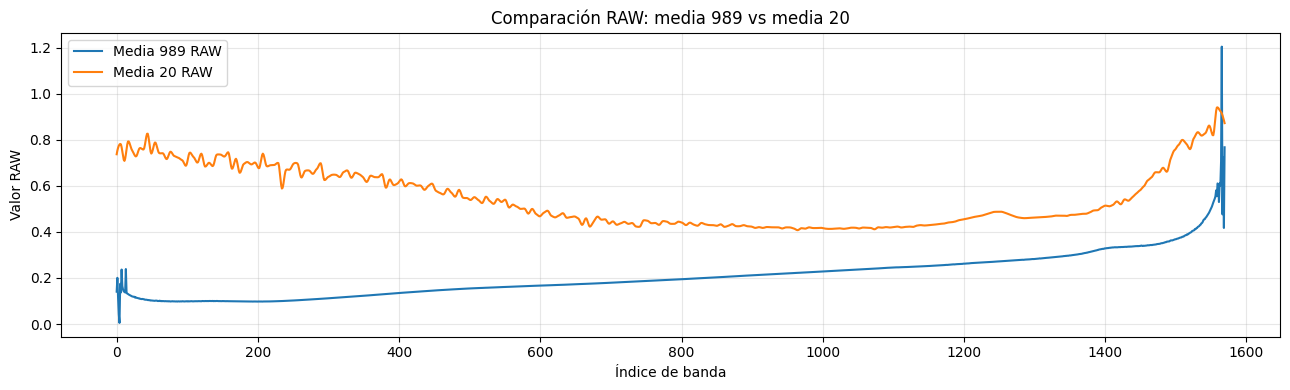

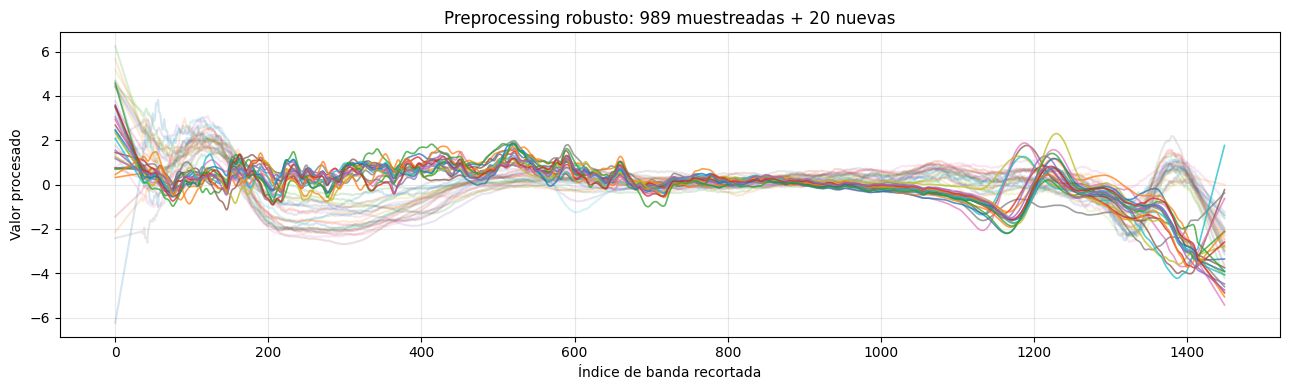

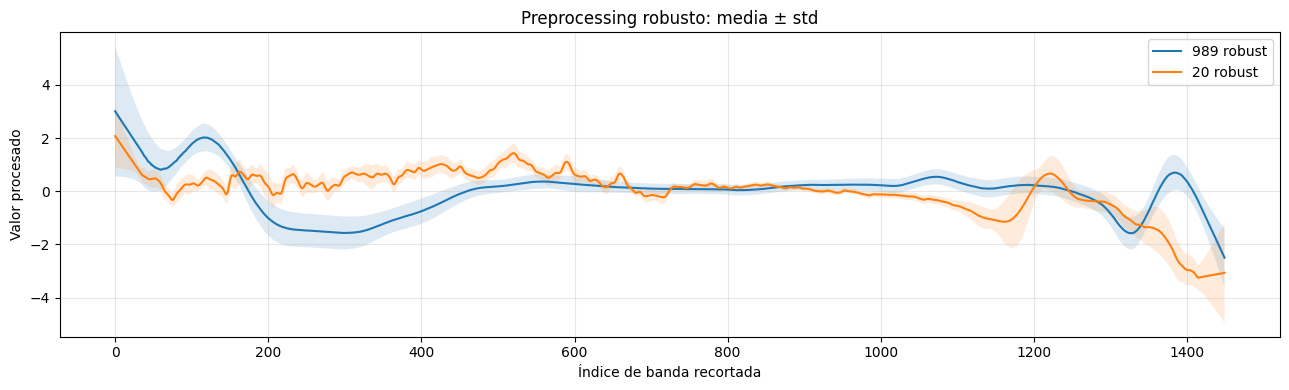

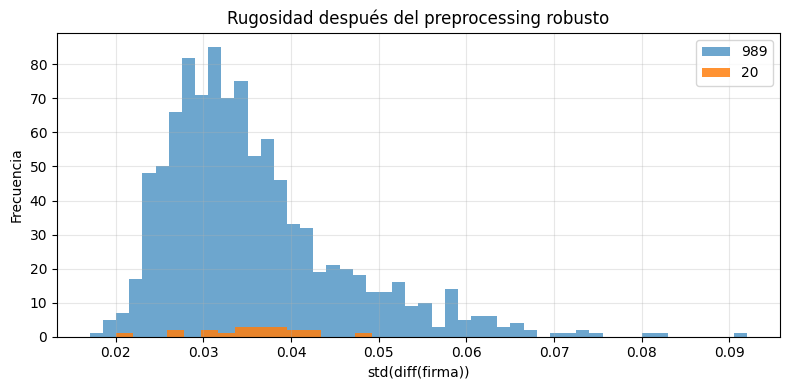

,conjunto,mediana_rugosidad,media_rugosidad,ratio_vs_989_mediana
0,989,0.0333,0.0356,1.000
1,20,0.0361,0.0356,1.082


In [87]:
def plot_mean_std(ax, X, label, alpha_fill=0.15):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    x = np.arange(X.shape[1])
    ax.plot(x, mean, label=label)
    ax.fill_between(x, mean - std, mean + std, alpha=alpha_fill)


def plot_essential_comparisons(X989_raw, X20_raw, X989_proc, X20_proc, n_989=25):
    rng = np.random.default_rng(RANDOM_STATE)
    idx_989 = rng.choice(X989_raw.shape[0], size=min(n_989, X989_raw.shape[0]), replace=False)

    # 1. RAW: medias
    plt.figure(figsize=(13, 4))
    plt.plot(X989_raw.mean(axis=0), label="Media 989 RAW")
    plt.plot(X20_raw.mean(axis=0), label="Media 20 RAW")
    plt.title("Comparación RAW: media 989 vs media 20")
    plt.xlabel("Índice de banda")
    plt.ylabel("Valor RAW")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "01_media_RAW_989_vs_20.png"), dpi=200)
    plt.show()

    # 2. Procesado: firmas individuales compactas
    plt.figure(figsize=(13, 4))
    for i in idx_989:
        plt.plot(X989_proc[i], alpha=0.18)
    for i in range(X20_proc.shape[0]):
        plt.plot(X20_proc[i], alpha=0.75, linewidth=1.2)
    plt.title("Preprocessing robusto: 989 muestreadas + 20 nuevas")
    plt.xlabel("Índice de banda recortada")
    plt.ylabel("Valor procesado")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "02_firmas_procesadas_989_vs_20.png"), dpi=200)
    plt.show()

    # 3. Procesado: media ± std
    fig, ax = plt.subplots(figsize=(13, 4))
    plot_mean_std(ax, X989_proc, "989 robust")
    plot_mean_std(ax, X20_proc, "20 robust")
    ax.set_title("Preprocessing robusto: media ± std")
    ax.set_xlabel("Índice de banda recortada")
    ax.set_ylabel("Valor procesado")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "03_media_std_robust_989_vs_20.png"), dpi=200)
    plt.show()

    # 4. Rugosidad
    r989 = roughness(X989_proc)
    r20 = roughness(X20_proc)

    plt.figure(figsize=(8, 4))
    plt.hist(r989, bins=50, alpha=0.65, label="989")
    plt.hist(r20, bins=15, alpha=0.85, label="20")
    plt.title("Rugosidad después del preprocessing robusto")
    plt.xlabel("std(diff(firma))")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "04_rugosidad_robust.png"), dpi=200)
    plt.show()

    rough_summary = pd.DataFrame([
        {"conjunto": "989", "mediana_rugosidad": np.median(r989), "media_rugosidad": np.mean(r989)},
        {"conjunto": "20", "mediana_rugosidad": np.median(r20), "media_rugosidad": np.mean(r20)},
    ])
    rough_summary["ratio_vs_989_mediana"] = rough_summary["mediana_rugosidad"] / rough_summary.loc[0, "mediana_rugosidad"]
    display(rough_summary.round(4))
    rough_summary.to_csv(os.path.join(OUT_DIR, "resumen_rugosidad.csv"), index=False)

plot_essential_comparisons(X_train_raw_989, X_new_raw, X_989_final, X_20_final)

# Chequeo compacto de cambio de dominio

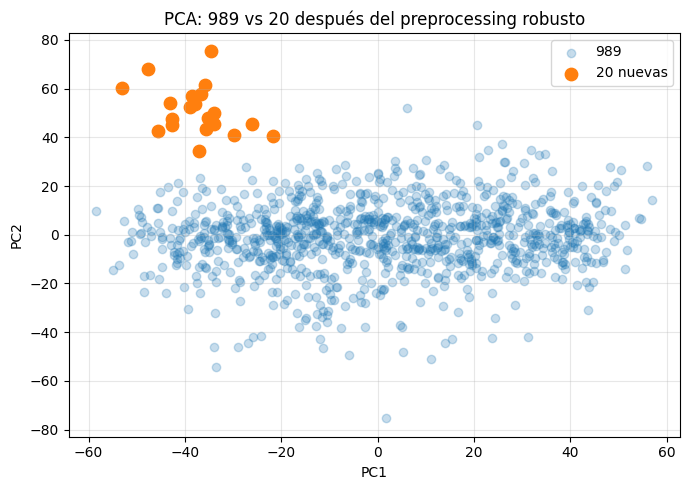

Resumen de distancias


,comparacion,mediana_distancia,media_distancia,max_distancia
0,20 -> vecino 989,30.0865,31.5359,38.5397
1,989 -> vecino 989,6.7901,7.1434,21.7443



Resumen de correspondencia por Numero


,mismo_Numero_vecino_1_n,total_20,rank_mediano_mismo_Numero,dist_mediana_mismo_Numero,dist_mediana_vecino_1
0,0,20,336.0,45.7175,30.0865



Tabla compacta por muestra


,Numero_20,split,vecino_989_mas_cercano,dist_vecino,rank_mismo_Numero,dist_mismo_Numero,mismo_Numero_es_vecino_1
0,1,test,908,36.0556,64,42.3307,False
1,53,test,872,34.0826,226,45.7492,False
2,105,train_20,797,36.7864,615,51.2747,False
3,157,test,908,28.0512,633,49.4093,False
4,209,train_20,857,36.8941,667,54.1060,False
5,261,test,908,33.6177,635,52.3088,False
6,313,train_20,908,36.0585,796,54.2785,False
7,365,train_20,908,38.5397,396,51.5115,False
8,417,test,908,31.6021,144,43.1498,False
9,469,train_20,908,29.5068,111,41.2003,False


In [88]:
def domain_check_compact(X989_proc, X20_proc, common_ids, df_20):
    # PCA visual
    X_all = np.vstack([X989_proc, X20_proc])
    labels = np.array(["989"] * X989_proc.shape[0] + ["20"] * X20_proc.shape[0])

    X_all_scaled = StandardScaler().fit_transform(X_all)
    Z = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_all_scaled)

    plt.figure(figsize=(7, 5))
    plt.scatter(Z[labels == "989", 0], Z[labels == "989", 1], alpha=0.25, label="989")
    plt.scatter(Z[labels == "20", 0], Z[labels == "20", 1], s=80, label="20 nuevas")
    plt.title("PCA: 989 vs 20 después del preprocessing robusto")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "05_PCA_robust_989_vs_20.png"), dpi=200)
    plt.show()

    # Distancias al vecino más cercano
    nn_20 = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(X989_proc)
    dist20, idx20 = nn_20.kneighbors(X20_proc)

    nn_989 = NearestNeighbors(n_neighbors=2, metric="euclidean").fit(X989_proc)
    dist989, _ = nn_989.kneighbors(X989_proc)
    dist989_real = dist989[:, 1]

    dist_summary = pd.DataFrame([
        {
            "comparacion": "20 -> vecino 989",
            "mediana_distancia": np.median(dist20),
            "media_distancia": np.mean(dist20),
            "max_distancia": np.max(dist20),
        },
        {
            "comparacion": "989 -> vecino 989",
            "mediana_distancia": np.median(dist989_real),
            "media_distancia": np.mean(dist989_real),
            "max_distancia": np.max(dist989_real),
        },
    ])

    print("Resumen de distancias")
    display(dist_summary.round(4))

    # Chequeo mismo Numero
    D = pairwise_distances(X20_proc, X989_proc, metric="euclidean")
    rows = []
    for i in range(X20_proc.shape[0]):
        numero = int(df_20.iloc[i]["Numero"])
        nearest_idx = int(np.argmin(D[i]))
        nearest_numero = int(common_ids[nearest_idx])
        same_positions = np.where(common_ids == numero)[0]

        if len(same_positions) > 0:
            same_idx = int(same_positions[0])
            same_dist = float(D[i, same_idx])
            same_rank = int(np.argsort(D[i]).tolist().index(same_idx) + 1)
        else:
            same_dist = np.nan
            same_rank = np.nan

        rows.append({
            "Numero_20": numero,
            "split": df_20.iloc[i]["split"],
            "vecino_989_mas_cercano": nearest_numero,
            "dist_vecino": float(D[i, nearest_idx]),
            "rank_mismo_Numero": same_rank,
            "dist_mismo_Numero": same_dist,
            "mismo_Numero_es_vecino_1": nearest_numero == numero,
        })

    same_df = pd.DataFrame(rows)

    same_summary = pd.DataFrame([{
        "mismo_Numero_vecino_1_n": int(same_df["mismo_Numero_es_vecino_1"].sum()),
        "total_20": len(same_df),
        "rank_mediano_mismo_Numero": same_df["rank_mismo_Numero"].median(),
        "dist_mediana_mismo_Numero": same_df["dist_mismo_Numero"].median(),
        "dist_mediana_vecino_1": same_df["dist_vecino"].median(),
    }])

    print("\nResumen de correspondencia por Numero")
    display(same_summary.round(4))

    print("\nTabla compacta por muestra")
    display(same_df.round(4))

    dist_summary.to_csv(os.path.join(OUT_DIR, "resumen_distancias_dominio.csv"), index=False)
    same_summary.to_csv(os.path.join(OUT_DIR, "resumen_mismo_numero.csv"), index=False)
    same_df.to_csv(os.path.join(OUT_DIR, "mismo_numero_por_muestra.csv"), index=False)

    return dist_summary, same_summary, same_df


dist_summary, same_summary, same_id_table = domain_check_compact(
    X_989_final,
    X_20_final,
    common_ids,
    df_20,
)

# Modelos clásicos compactos: PLSR/RF

In [89]:
def make_weighted_training_set(X989, y989, X20_train, y20_train, repeat_new=1):
    X_new_rep = np.repeat(X20_train, repeat_new, axis=0)
    y_new_rep = np.repeat(y20_train, repeat_new, axis=0)
    X_combined = np.vstack([X989, X_new_rep])
    y_combined = np.concatenate([y989, y_new_rep])
    return X_combined, y_combined


def evaluate_classic_models_compact(target, X989_proc, X20_proc):
    rows = []

    y989 = y_all_df[target].values.astype(float)
    y20 = df_20[target].values.astype(float)

    X20_train = X20_proc[train_idx]
    X20_test = X20_proc[test_idx]
    y20_train = y20[train_idx]
    y20_test = y20[test_idx]

    # Baseline promedio de las 10 nuevas train
    pred_base = np.full_like(y20_test, np.mean(y20_train), dtype=float)
    rows.append({"target": target, "modelo": "Baseline media 10 train", "repeat_new": 0, "n_comp": np.nan, **regression_metrics(y20_test, pred_base)})

    # PLSR: 989 + nuevas repetidas
    for repeat_new in NEW_DOMAIN_REPEATS:
        Xtr, ytr = make_weighted_training_set(X989_proc, y989, X20_train, y20_train, repeat_new=repeat_new)
        for n_comp in PLS_COMPONENTS_GRID:
            max_comp = min(n_comp, Xtr.shape[0] - 1, Xtr.shape[1])
            if max_comp < 1:
                continue
            model = make_pipeline(StandardScaler(), PLSRegression(n_components=max_comp))
            model.fit(Xtr, ytr)
            pred = model.predict(X20_test).reshape(-1)
            rows.append({"target": target, "modelo": "PLSR 989+20 ponderado", "repeat_new": repeat_new, "n_comp": max_comp, **regression_metrics(y20_test, pred)})

    # RF: 989 + nuevas repetidas
    for repeat_new in NEW_DOMAIN_REPEATS:
        Xtr, ytr = make_weighted_training_set(X989_proc, y989, X20_train, y20_train, repeat_new=repeat_new)
        model = RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
        model.fit(Xtr, ytr)
        pred = model.predict(X20_test)
        rows.append({"target": target, "modelo": "RF 989+20 ponderado", "repeat_new": repeat_new, "n_comp": np.nan, **regression_metrics(y20_test, pred)})

    results = pd.DataFrame(rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)

    print(f"\nResultados clásicos compactos - {target}")
    display(results.head(8).round(4))
    results.to_csv(os.path.join(OUT_DIR, f"resultados_clasicos_{target}.csv"), index=False)
    return results


results_pH_classic = evaluate_classic_models_compact("pH", X_989_final, X_20_final)
results_Ca_classic = evaluate_classic_models_compact("Ca", X_989_final, X_20_final)


Resultados clásicos compactos - pH


,target,modelo,repeat_new,n_comp,RMSE,MAE,R2,Bias
0,pH,PLSR 989+20 ponderado,5,5.0,0.9250,0.7355,0.1697,0.1040
1,pH,RF 989+20 ponderado,20,NaN,0.9510,0.8430,0.1224,0.2192
2,pH,PLSR 989+20 ponderado,20,5.0,1.0006,0.7960,0.0284,0.0646
3,pH,PLSR 989+20 ponderado,1,10.0,1.0428,0.8418,-0.0552,0.5453
4,pH,PLSR 989+20 ponderado,1,5.0,1.0521,0.9222,-0.0741,0.4870
5,pH,PLSR 989+20 ponderado,5,10.0,1.0633,0.9065,-0.0971,0.0275
6,pH,PLSR 989+20 ponderado,20,2.0,1.0865,0.9486,-0.1454,0.3037
7,pH,Baseline media 10 train,0,NaN,1.1360,1.1060,-0.2524,0.5100



Resultados clásicos compactos - Ca


,target,modelo,repeat_new,n_comp,RMSE,MAE,R2,Bias
0,Ca,RF 989+20 ponderado,20,NaN,7.8313,7.2942,0.1664,2.9420
1,Ca,PLSR 989+20 ponderado,5,5.0,9.0567,7.7762,-0.1149,3.6495
2,Ca,PLSR 989+20 ponderado,20,5.0,9.6680,8.5007,-0.2705,3.8796
3,Ca,PLSR 989+20 ponderado,5,10.0,9.9735,8.7802,-0.3520,4.0405
4,Ca,RF 989+20 ponderado,5,NaN,10.1510,7.8169,-0.4006,4.3223
5,Ca,PLSR 989+20 ponderado,1,5.0,10.1713,8.7158,-0.4062,6.2653
6,Ca,PLSR 989+20 ponderado,20,2.0,10.4894,9.4478,-0.4955,4.9022
7,Ca,PLSR 989+20 ponderado,1,10.0,10.7785,9.0255,-0.5791,7.6119


# CNN: arquitectura y utilidades de fine tuning

In [90]:
class FineTuneSpectraDataset(Dataset):
    def __init__(self, X, y_scaled):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y_scaled, dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class ResBlock(nn.Module):
    def __init__(self, channels: int, p: float = 0.1, dilation: int = 1):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout(p)

    def forward(self, x):
        identity = x
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.bn2(self.conv2(x))
        return torch.relu(x + identity)


BaseLightning = pl.LightningModule if pl is not None else nn.Module

class Conv1DRegressor(BaseLightning):
    def __init__(self, input_length: int):
        super().__init__()
        if hasattr(self, "save_hyperparameters"):
            self.save_hyperparameters()

        self.conv_stem = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.res = nn.Sequential(
            ResBlock(64, p=0.10, dilation=1),
            ResBlock(64, p=0.10, dilation=2),
        )

        self.pool = nn.AdaptiveAvgPool1d(8)
        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(64 * 8, 64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.conv_stem(x)
        x = self.res(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x


def load_cnn_checkpoint_flexible(ckpt_path, input_length, device="cpu"):
    if pl is not None:
        try:
            model = Conv1DRegressor.load_from_checkpoint(ckpt_path, input_length=input_length, map_location=device)
            return model.to(device)
        except Exception as e:
            print("Carga con Lightning falló; intento con state_dict manual.")
            print("Detalle:", repr(e))

    model = Conv1DRegressor(input_length=input_length)
    ckpt = torch.load(ckpt_path, map_location=device)
    state = ckpt.get("state_dict", ckpt)
    clean_state = {}
    for k, v in state.items():
        nk = k.replace("model.", "")
        clean_state[nk] = v
    missing, unexpected = model.load_state_dict(clean_state, strict=False)
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)
    return model.to(device)


def freeze_for_finetune(model, mode="head"):
    for p in model.parameters():
        p.requires_grad = False

    if mode == "head":
        for p in model.fc.parameters():
            p.requires_grad = True
    elif mode == "stem_fc":
        for p in model.conv_stem.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
    elif mode == "all":
        for p in model.parameters():
            p.requires_grad = True
    else:
        raise ValueError("mode debe ser 'head', 'stem_fc' o 'all'")

    return model


def set_batchnorm_eval(model):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm1d):
            m.eval()
            for p in m.parameters():
                p.requires_grad = False


@torch.no_grad()
def predict_cnn(model, X_proc, y_scaler, device="cpu"):
    model.eval()
    X_tensor = torch.tensor(X_proc, dtype=torch.float32).unsqueeze(1).to(device)
    pred_scaled = model(X_tensor).detach().cpu().numpy().reshape(-1, 1)
    pred_real = y_scaler.inverse_transform(pred_scaled).reshape(-1)
    return pred_real

# CNN preentrenada + fine-tuning exploratorio

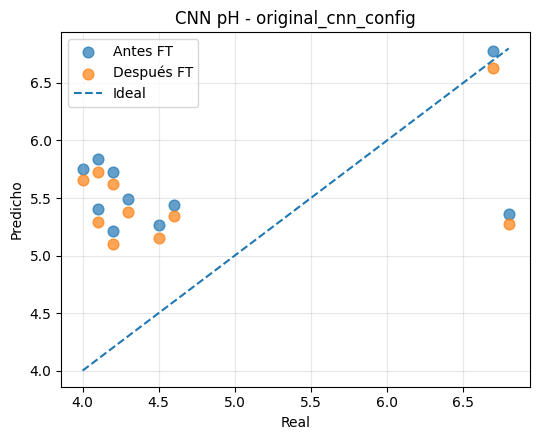

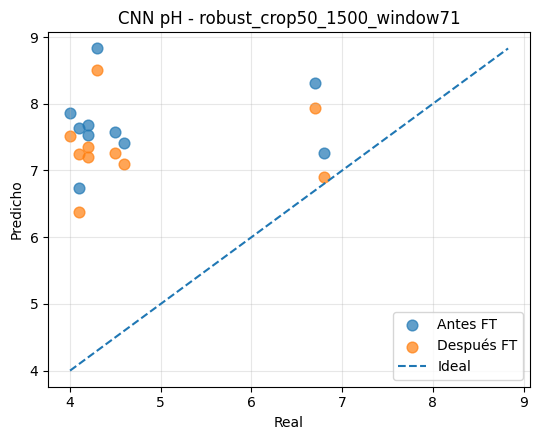

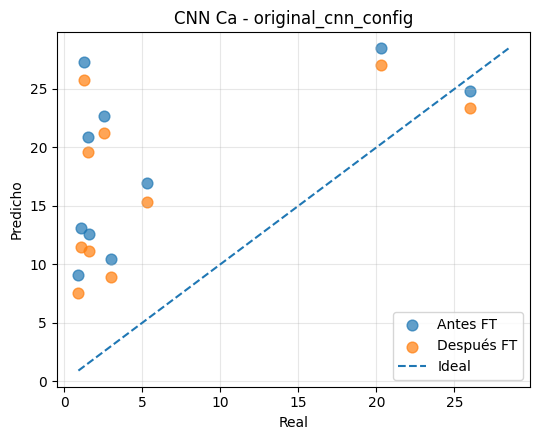

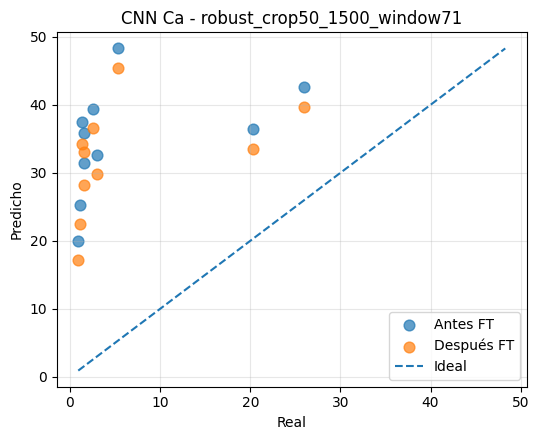


Resumen compacto CNN


,target,preprocessing,freeze_mode,train_RMSE_antes,test_RMSE_antes,train_RMSE_despues,test_RMSE_despues,test_R2_antes,test_R2_despues,test_Bias_despues
0,pH,original_cnn_config,head,1.6258,1.2628,1.5837,1.1869,-0.5475,-0.3671,0.7656
1,pH,robust_crop50_1500_window71,head,2.8179,3.1349,2.4985,2.8193,-8.5369,-6.7134,2.5892
2,Ca,original_cnn_config,head,16.1086,14.3091,15.5048,13.0415,-1.7830,-1.3118,10.7717
3,Ca,robust_crop50_1500_window71,head,23.7139,29.9025,21.1700,27.1383,-11.1536,-9.0105,25.6724


In [91]:
# Nota: esta celda prueba dos entradas para la CNN.
# 1. Preprocessing original guardado con la CNN.
# 2. pPreprocessing nuevo propuesto.
#
# La opción nueva es exploratoria: la CNN no fue entrenada originalmente con ese preprocessing.


def fine_tune_cnn_one_target(target, X_proc, preprocessing_name, epochs=FINETUNE_EPOCHS, lr=FINETUNE_LR, freeze_mode=FREEZE_MODE):
    ckpt_path = PRETRAINED_CKPTS[target]
    y_scaler = joblib.load(PRETRAINED_ARTIFACTS[target]["y_scaler"])

    y_real = df_20[target].values.astype(np.float32)
    y_scaled = y_scaler.transform(y_real.reshape(-1, 1)).astype(np.float32).reshape(-1)

    X_train = X_proc[train_idx]
    y_train_scaled = y_scaled[train_idx]
    y_train_real = y_real[train_idx]

    X_test = X_proc[test_idx]
    y_test_real = y_real[test_idx]

    model = load_cnn_checkpoint_flexible(ckpt_path, input_length=X_proc.shape[1], device=device)
    model = freeze_for_finetune(model, mode=freeze_mode)

    y_before_all = predict_cnn(model, X_proc, y_scaler, device=device)
    metrics_train_before = regression_metrics(y_train_real, y_before_all[train_idx])
    metrics_test_before = regression_metrics(y_test_real, y_before_all[test_idx])

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)
    criterion = nn.SmoothL1Loss()

    dl = DataLoader(
        FineTuneSpectraDataset(X_train, y_train_scaled),
        batch_size=BATCH_SIZE_FT,
        shuffle=True,
    )

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        set_batchnorm_eval(model)
        losses = []
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        pred_train = predict_cnn(model, X_train, y_scaler, device=device)
        mt = regression_metrics(y_train_real, pred_train)
        history.append({"epoch": epoch, "loss_scaled": np.mean(losses), "train_RMSE": mt["RMSE"], "train_R2": mt["R2"]})

    y_after_all = predict_cnn(model, X_proc, y_scaler, device=device)
    metrics_train_after = regression_metrics(y_train_real, y_after_all[train_idx])
    metrics_test_after = regression_metrics(y_test_real, y_after_all[test_idx])

    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(OUT_DIR, f"cnn_history_{target}_{preprocessing_name}.csv"), index=False)

    # Gráfico real vs predicho después
    pred_df = df_20.iloc[test_idx][["Numero", target]].copy()
    pred_df = pred_df.rename(columns={target: "real"})
    pred_df["pred_antes"] = y_before_all[test_idx]
    pred_df["pred_despues"] = y_after_all[test_idx]
    pred_df["error_despues"] = pred_df["pred_despues"] - pred_df["real"]
    pred_df.to_csv(os.path.join(OUT_DIR, f"cnn_predicciones_{target}_{preprocessing_name}.csv"), index=False)

    plt.figure(figsize=(5.5, 4.5))
    plt.scatter(pred_df["real"], pred_df["pred_antes"], s=60, alpha=0.7, label="Antes FT")
    plt.scatter(pred_df["real"], pred_df["pred_despues"], s=60, alpha=0.7, label="Después FT")
    mn = min(pred_df["real"].min(), pred_df["pred_antes"].min(), pred_df["pred_despues"].min())
    mx = max(pred_df["real"].max(), pred_df["pred_antes"].max(), pred_df["pred_despues"].max())
    plt.plot([mn, mx], [mn, mx], "--", label="Ideal")
    plt.title(f"CNN {target} - {preprocessing_name}")
    plt.xlabel("Real")
    plt.ylabel("Predicho")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"cnn_scatter_{target}_{preprocessing_name}.png"), dpi=200)
    plt.show()

    return {
        "target": target,
        "preprocessing": preprocessing_name,
        "freeze_mode": freeze_mode,
        "train_RMSE_antes": metrics_train_before["RMSE"],
        "test_RMSE_antes": metrics_test_before["RMSE"],
        "train_RMSE_despues": metrics_train_after["RMSE"],
        "test_RMSE_despues": metrics_test_after["RMSE"],
        "test_R2_antes": metrics_test_before["R2"],
        "test_R2_despues": metrics_test_after["R2"],
        "test_Bias_despues": metrics_test_after["Bias"],
    }


cnn_rows = []

for target in ["pH", "Ca"]:
    # CNN con preprocessing original guardado
    original_config = joblib.load(PRETRAINED_ARTIFACTS[target]["config"])
    X20_original_cnn = preprocess_X_from_config(X_new_raw, original_config)
    cnn_rows.append(
        fine_tune_cnn_one_target(
            target=target,
            X_proc=X20_original_cnn,
            preprocessing_name="original_cnn_config",
            epochs=FINETUNE_EPOCHS,
            lr=FINETUNE_LR,
            freeze_mode=FREEZE_MODE,
        )
    )

    # CNN con preprocessing robusto propuesto
    cnn_rows.append(
        fine_tune_cnn_one_target(
            target=target,
            X_proc=X_20_final,
            preprocessing_name="robust_crop50_1500_window71",
            epochs=FINETUNE_EPOCHS,
            lr=FINETUNE_LR,
            freeze_mode=FREEZE_MODE,
        )
    )

cnn_summary = pd.DataFrame(cnn_rows)
print("\nResumen compacto CNN")
display(cnn_summary.round(4))
cnn_summary.to_csv(os.path.join(OUT_DIR, "resumen_CNN_finetuning.csv"), index=False)

# Resumeeeen

In [92]:
best_classic = pd.concat([
    results_pH_classic.head(1),
    results_Ca_classic.head(1),
], ignore_index=True)

best_classic = best_classic.rename(columns={
    "modelo": "metodo",
    "RMSE": "test_RMSE",
    "MAE": "test_MAE",
    "R2": "test_R2",
    "Bias": "test_Bias",
})

best_classic["familia"] = "Clásico"
best_classic = best_classic[["familia", "target", "metodo", "repeat_new", "n_comp", "test_RMSE", "test_MAE", "test_R2", "test_Bias"]]

best_cnn = cnn_summary.sort_values(["target", "test_RMSE_despues"]).groupby("target").head(1).copy()
best_cnn = best_cnn.rename(columns={
    "preprocessing": "metodo",
    "test_RMSE_despues": "test_RMSE",
    "test_R2_despues": "test_R2",
    "test_Bias_despues": "test_Bias",
})
best_cnn["familia"] = "CNN fine-tuning"
best_cnn["repeat_new"] = np.nan
best_cnn["n_comp"] = np.nan
best_cnn["test_MAE"] = np.nan
best_cnn = best_cnn[["familia", "target", "metodo", "repeat_new", "n_comp", "test_RMSE", "test_MAE", "test_R2", "test_Bias"]]

final_summary = pd.concat([best_classic, best_cnn], ignore_index=True)

print("Resumen final compacto")
display(final_summary.round(4))

final_summary.to_csv(os.path.join(OUT_DIR, "resumen_final_compacto.csv"), index=False)

print("\nArchivos guardados en:", OUT_DIR)

Resumen final compacto


,familia,target,metodo,repeat_new,n_comp,test_RMSE,test_MAE,test_R2,test_Bias
0,Clásico,pH,PLSR 989+20 ponderado,5.0,5.0,0.9250,0.7355,0.1697,0.1040
1,Clásico,Ca,RF 989+20 ponderado,20.0,NaN,7.8313,7.2942,0.1664,2.9420
2,CNN fine-tuning,Ca,original_cnn_config,NaN,NaN,13.0415,NaN,-1.3118,10.7717
3,CNN fine-tuning,pH,original_cnn_config,NaN,NaN,1.1869,NaN,-0.3671,0.7656



Archivos guardados en: cuadernillo_comparativo_989_vs_20
